In [ ]:
import os
import requests
from dotenv import load_dotenv

from typing import TypedDict, List

from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


In [48]:
load_dotenv()

ALPHAVANTAGE_API_KEY = os.getenv("ALPHAVANTAGE_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
WEATHERSTACK_API_KEY = os.getenv("WEATHERSTACK_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


In [49]:
model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    api_key=GOOGLE_API_KEY,
    temperature=0.3
)


## tool 

In [50]:
#tools 
@tool
def sum_calculator(a: float, b: float) -> float:
    """Add two numbers and return numeric result"""
    return a + b


In [51]:
@tool
def get_stock_price(symbol: str) -> float:
    """Fetch latest closing stock price using AlphaVantage"""
    
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": symbol,
        "apikey": ALPHAVANTAGE_API_KEY
    }

    response = requests.get(url, params=params).json()

    try:
        latest_date = list(response["Time Series (Daily)"].keys())[0]
        price = float(response["Time Series (Daily)"][latest_date]["4. close"])
        return price
    except:
        return 0.0


In [52]:
@tool
def get_temperature(city: str) -> float:
    """Fetch today's temperature"""
    
    url = "http://api.weatherstack.com/current"
    params = {
        "access_key": WEATHERSTACK_API_KEY,
        "query": city
    }

    response = requests.get(url, params=params).json()

    try:
        return float(response["current"]["temperature"])
    except:
        return 0.0


In [53]:
@tool
def search_internet(query: str) -> str:
    """Fetch today's information from internet using Tavily"""
    
    url = "https://api.tavily.com/search"
    headers = {"Content-Type": "application/json"}
    
    payload = {
        "api_key": TAVILY_API_KEY,
        "query": query,
        "search_depth": "basic"
    }

    response = requests.post(url, json=payload, headers=headers).json()

    try:
        return response["results"][0]["content"]
    except:
        return "No search results found"


In [54]:
#tool binding 
tools = [sum_calculator,get_stock_price,get_temperature,search_internet
]

model_with_tools = model.bind_tools(tools)


## graph implementation

In [65]:
#state
from typing import Annotated
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]


In [66]:
#create Graph 
graph = StateGraph(AgentState)


In [67]:
#llm node 
def llm_node(state: AgentState):
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}



In [68]:
#tool node 
tool_node = ToolNode(tools)


In [69]:
#adding nodes 
graph.add_node("llm", llm_node)
graph.add_node("tools", tool_node)


In [70]:
#adding edges 
graph.add_edge(START, "llm")

graph.add_conditional_edges(
    "llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

graph.add_edge("tools", "llm")


In [71]:
#Compile Graph
app = graph.compile()



In [72]:
#example code 
result = app.invoke({
    "messages": [
        HumanMessage(
            content="Fetch today's stock price of AAPL and MSFT and add them"
        )
    ]
})


In [80]:
print (result["messages"])

[HumanMessage(content="Fetch today's stock price of AAPL and MSFT and add them", additional_kwargs={}, response_metadata={}, id='f6c6bf6f-db38-4bff-8674-ac6d9900f994'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "MSFT"}'}, '__gemini_function_call_thought_signatures__': {'e85e33f8-576b-4b83-8fcd-f6a47881b805': 'CuICAb4+9vttZSFJtvOtenJ8gtx7TN75arIaWNAc94JtJXRGClLOIqV98SRDDsxLXstGuMo3g9jADZwSzxsFyRW455LxU84gBSNRYVWSxRMZabHaVc2C22AIy34Htc1JtMGITWjS7yokXsJ+JWj03513pMgvePizMP3vuZi75Sor0f7gzaJH9bQc79VlasTHchbUY+htN9A81b6OIJtGNX0aPyXaWJMuEjHk4OUQtORgLOVKtqYClDco/lmL6B0/qGkZ13MBZVsq+DhnZEke039DwCvzdmfiZJn5JtSrPBSdIk8g88wwKt5BRXqd0BbTflz2tIAx1Ln9dj23bHsHCc3nUOJ7kMsekqV81V6My0hOB5dKlS3gif4PovBR911ywL7TQMfgpg8dFWaRM7k9JE5kQOnO/G8H/ko7YXXXnkopICMYuS89TCGr6HgIWxeKLfNxie6UWrWdTeaRkfXnFyA9Zu7K'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='

In [73]:
for msg in result["messages"]:
    print(type(msg).__name__, ":", msg.content)


HumanMessage : Fetch today's stock price of AAPL and MSFT and add them
AIMessage : 
ToolMessage : 255.78
ToolMessage : 401.32
AIMessage : 
ToolMessage : 657.1
AIMessage : [{'type': 'text', 'text': 'The sum of AAPL and MSFT stock prices is 657.1.', 'extras': {'signature': 'CqUBAb4+9vuaX2ZeoCMKaOg6DUz4T0ISWwm0wfr9gwSt+ogaG4V9Br6ZRa1mvkH16f751KtND7kZwXKOgzZ+Zo31J62Ul90l4pVqlMj5W4rC4Pe/ms0zHUi6fgQxGD9NUOtaNrGiiYeErO7dno0x48Xf3pT0drtFbg1+dKAQL354+0w19qlBSZVNTItp2NtgGSXOxNRXWt9ihCjgUUWxYEvjG9HEIUQ/'}}]


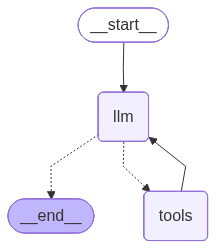

In [74]:
graph.compile()